<a href="https://colab.research.google.com/github/waelydz/ASD-Sense/blob/main/Model_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup and Data Acquisition

In [1]:
!pip install tf-keras tensorflow_hub kagglehub scikit-learn -q

import os
# CRITICAL FIX: Force TensorFlow to use Keras 2 to match TF Hub
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.utils.class_weight import compute_class_weight

# Download dataset
dataset_path = kagglehub.dataset_download('imranliaqat32/autism-spectrum-disorder-in-childrenhandgestures')

DATA_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if 'ASD' in dirs and 'Non-ASD' in dirs:
        DATA_DIR = root
        break

if not DATA_DIR:
    raise FileNotFoundError("Target class directories 'ASD' and 'Non-ASD' not found.")

Using Colab cache for faster access to the 'autism-spectrum-disorder-in-childrenhandgestures' dataset.


Data Pipeline and Class Weight Computation

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 224

data = []
# Iterate through all available folders in the target directory
for category_folder in os.listdir(DATA_DIR):
    category_path = os.path.join(DATA_DIR, category_folder)
    if not os.path.isdir(category_path):
        continue

    # Map 'Non-ASD' to 0, and aggregate BOTH 'ASD' and 'ASD with CD' to 1
    label = 0 if category_folder == 'Non-ASD' else 1

    for root_dir, _, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append({'filepath': os.path.join(root_dir, file), 'label': label})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Train/val split directly from the aggregated dataframe
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Calculate algorithmic class weights to handle imbalance without synthetic data
weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_dict = {0: weights[0], 1: weights[1]}

# Custom pipeline function to load images and apply ViT pixel scaling [-1, 1]
def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = (img / 127.5) - 1.0
    return img, label

# Build high-performance tf.data pipelines directly from the dataframes
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label'].values))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_df['label'].values))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset aggregation and ViT pipeline successfully built.")

Dataset aggregation and ViT pipeline successfully built.


Model Initialization and Training

In [3]:
print("Building Pre-Trained ViT Model with Augmentation...")
vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"

vit_layer = hub.KerasLayer(vit_url, trainable=False, name='vit_layer')

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    # --- NEW: Data Augmentation layers to make the learning curve normal ---
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    # ----------------------------------------------------------------------

    vit_layer,
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting Initial Training (5 Epochs)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights_dict
)

Building Pre-Trained ViT Model with Augmentation...
Starting Initial Training (5 Epochs)...
Epoch 1/5
44/44 [==============================] - 27s 385ms/step - loss: 0.2504 - accuracy: 0.8965 - val_loss: 0.3181 - val_accuracy: 0.8937
Epoch 2/5
44/44 [==============================] - 4s 95ms/step - loss: 0.1131 - accuracy: 0.9518 - val_loss: 0.1590 - val_accuracy: 0.9397
Epoch 3/5
44/44 [==============================] - 4s 95ms/step - loss: 0.0856 - accuracy: 0.9655 - val_loss: 0.1054 - val_accuracy: 0.9540
Epoch 4/5
44/44 [==============================] - 4s 97ms/step - loss: 0.0668 - accuracy: 0.9806 - val_loss: 0.0757 - val_accuracy: 0.9713
Epoch 5/5
44/44 [==============================] - 4s 94ms/step - loss: 0.0641 - accuracy: 0.9784 - val_loss: 0.0948 - val_accuracy: 0.9626


Evaluation Metrics

In [4]:
print("\nUnfreezing ViT Backbone for Fine-Tuning...")
# Unfreeze the ViT layer to push for maximum accuracy
vit_layer.trainable = True

# Recompile with a significantly lower learning rate to protect the pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning (15 Epochs)...")
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict
)

final_val_acc = fine_tune_history.history['val_accuracy'][-1] * 100
print(f"\nViT Final Validation Accuracy: {final_val_acc:.2f}%")


Unfreezing ViT Backbone for Fine-Tuning...
Starting Fine-Tuning (15 Epochs)...
Epoch 1/15
44/44 [==============================] - 1010s 12s/step - loss: 0.0538 - accuracy: 0.9820 - val_loss: 0.0643 - val_accuracy: 0.9713
Epoch 2/15
44/44 [==============================] - 210s 5s/step - loss: 0.0317 - accuracy: 0.9885 - val_loss: 0.0512 - val_accuracy: 0.9856
Epoch 3/15
44/44 [==============================] - 210s 5s/step - loss: 0.0311 - accuracy: 0.9935 - val_loss: 0.0410 - val_accuracy: 0.9885
Epoch 4/15
44/44 [==============================] - 210s 5s/step - loss: 0.0212 - accuracy: 0.9928 - val_loss: 0.0541 - val_accuracy: 0.9828
Epoch 5/15
44/44 [==============================] - 210s 5s/step - loss: 0.0188 - accuracy: 0.9928 - val_loss: 0.0351 - val_accuracy: 0.9914
Epoch 6/15
44/44 [==============================] - 210s 5s/step - loss: 0.0097 - accuracy: 0.9978 - val_loss: 0.0397 - val_accuracy: 0.9914
Epoch 7/15
44/44 [==============================] - 210s 5s/step - loss:

Visualization

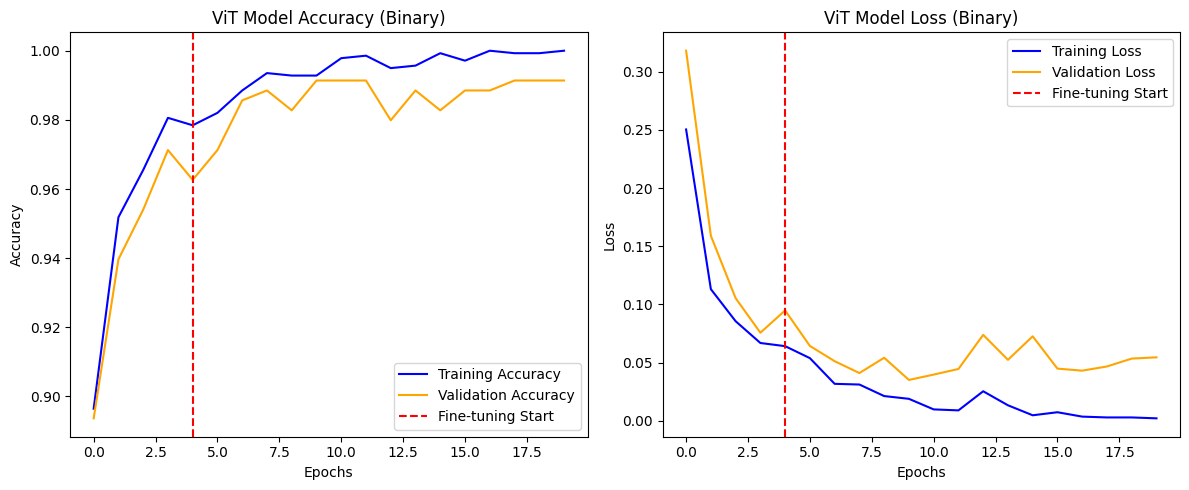

In [5]:
import matplotlib.pyplot as plt

def plot_results(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', color='blue')
    plt.plot(val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=len(hist1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('ViT Model Accuracy (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=len(hist1.history['loss'])-1, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('ViT Model Loss (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('vit_training_results.png', dpi=300)
    plt.show()

plot_results(history, fine_tune_history)